# KNN Regression with California Housing Dataset

## Step 1: Import necessary libraries

In [4]:
from sklearn.datasets import fetch_california_housing    # Load the dataset
from sklearn.model_selection import train_test_split     # Split the dataset
from sklearn.neighbors import KNeighborsRegressor        # KNN Regressor
from sklearn.metrics import mean_squared_error           # Evaluation metric
import numpy as np                                        # For calculations
import matplotlib.pyplot as plt                           # For plotting graphs
import seaborn as sns                                    # For more advanced visualizations

We import all the necessary libraries for the task:

fetch_california_housing to get the dataset.

train_test_split to split the data into training and testing sets.

KNeighborsRegressor to apply KNN for regression.

mean_squared_error to measure how well the model is doing.

matplotlib and seaborn for plotting the graphs (for visual evaluation).


## Step 2: Load the California Housing dataset

In [7]:
housing = fetch_california_housing()

# Display feature names and target
print("Feature names:", housing.feature_names)
print("Target: Median house value")

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median house value


The California Housing dataset contains features like:

Average number of rooms, population, income, etc.

The target is the median house value, which is what we will try to predict.

 ## Step 3: Prepare features (X) and target (y)

In [11]:
X = housing.data  # Features: info about each house area
y = housing.target  # Target: median house value

X represents the features, which are the input data (like number of rooms, income).

y represents the target, which is the median house value that we want to predict.

##  Step 4: Split into train and test sets (80% train, 20% test)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We use train_test_split to divide the data into two parts:

Training data (80%) is used to train the model.

Test data (20%) is used to evaluate the model after training.

 ## Step 5: Create and train the KNN Regressor

In [18]:
knn_reg = KNeighborsRegressor(n_neighbors=3)  # Using K = 3 neighbors
knn_reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

Here, we create a KNN Regressor with K = 3 (we look at 3 nearest neighbors to make a prediction).

We then train the model using the training data (X_train, y_train), so it can learn the relationships between features and target values.

## Step 6: Predict the target values on the test set

In [23]:
y_pred = knn_reg.predict(X_test)

### Show a few predicted vs actual values for comparison

In [27]:
print("Predicted:", y_pred[:5])  # Display first 5 predictions
print("Actual:   ", y_test[:5])  # Display first 5 actual values

Predicted: [1.79733333 1.25233333 2.82233333 2.429      1.493     ]
Actual:    [0.477   0.458   5.00001 2.186   2.78   ]


After training, we use the model to predict house prices on the test data (X_test).

The predictions are stored in y_pred, and we compare these predictions with the actual values (y_test) to see how well the model did.


## Step 7: Evaluate the model using Mean Squared Error (MSE)

In [31]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.1694144088518572


MSE (Mean Squared Error) gives us a measure of how close the model’s predictions are to the actual values.

Lower MSE = better predictions.

It’s calculated by averaging the squared differences between predicted and actual values.

##  Step 8: Add Visualizations

### Predicted vs Actual Plot

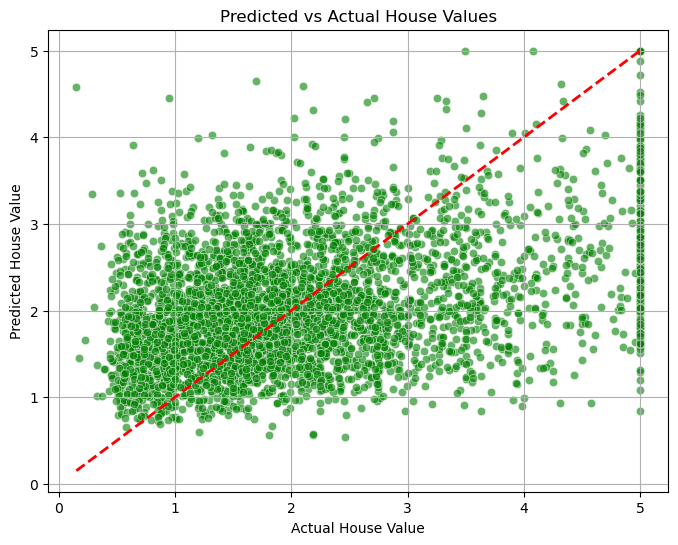

In [37]:
# Create a scatter plot to compare predicted vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Predicted vs Actual House Values')
plt.grid(True)
plt.show()

Scatter plot compares the predicted house prices (y_pred) with the actual house prices (y_test).

The red dashed line represents the ideal scenario where predicted values are exactly equal to actual values.

If the points are close to this line, the model is doing a good job.

### Residual Plot (Error Visualization)

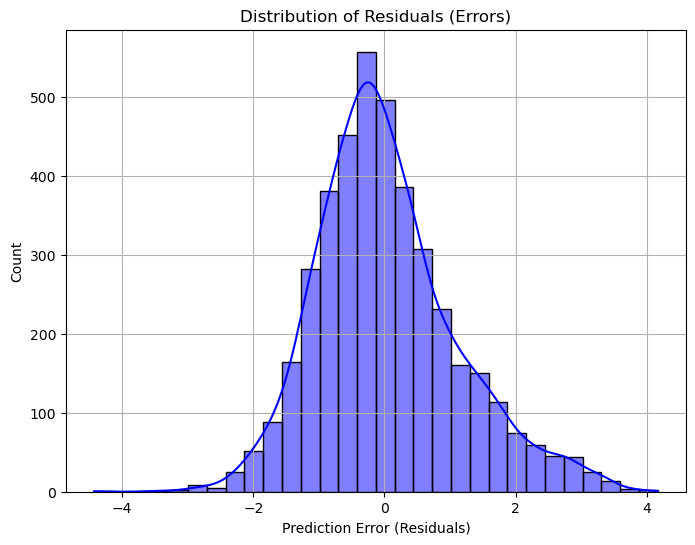

In [40]:
# Residuals = Actual - Predicted (errors)
residuals = y_test - y_pred

# Create a histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.xlabel('Prediction Error (Residuals)')
plt.title('Distribution of Residuals (Errors)')
plt.grid(True)
plt.show()

Residuals are the differences between actual values and predicted values (i.e., how far off the predictions were).

This histogram shows the distribution of residuals.

If the residuals are centered around 0 and have a small spread, it means the model is doing well.

Large errors (residuals far from 0) suggest the model’s predictions aren’t accurate.

Final Summary (With Visualizations)

Step	Task

1–7	Build and evaluate KNN regressor (including MSE)

8.1	Visualize predicted vs actual prices (scatter plot)

8.2	Plot residuals (errors) to evaluate prediction quality
